In [ ]:
#1.
from sklearn.datasets import load_wine
import pandas as pd

X, y = load_wine(return_X_y=True, as_frame=True)

Perform Recursive Feature Elimination (RFE) using Logistic Regression to select the top 3 features.

Expected Output:
Top 3 selected features using RFE: ['alcohol', 'flavanoids', 'od280/od315_of_diluted_wines']


In [15]:
#1.Answer
from sklearn.datasets import load_wine
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


X, y = load_wine(return_X_y=True, as_frame=True)


# Split into training and testing sets to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the data (Crucial for the 'saga' solver)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)


##Perform Recursive Feature Elimination (RFE) using Logistic Regression to select the top 3 features

n=3 ##to select the top 3 features
LR=LogisticRegression(solver='saga',max_iter=1000, random_state=42)
rfe=RFE(LR,n_features_to_select=n)
rfe_fit=rfe.fit(X_train_scaled,y_train)
rfe_feature=rfe_fit.transform(X_train_scaled)
print(rfe_fit.get_feature_names_out())


['flavanoids' 'color_intensity' 'proline']


In [16]:
#ans-Top 3 selected features using RFE: ['flavanoids', 'color_intensity', 'proanthocyanins']
from sklearn.datasets import load_wine
import pandas as pd

X, y = load_wine(return_X_y=True, as_frame=True)
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE

# Initialize Logistic Regression model
model = LogisticRegression(max_iter=10000)

# Perform RFE
selector = RFE(model, n_features_to_select=3)
selector.fit(X, y)

# Get the selected features
selected_features = X.columns[selector.support_]
print("Top 3 selected features using RFE:", list(selected_features))


Top 3 selected features using RFE: ['alcohol', 'flavanoids', 'od280/od315_of_diluted_wines']


In [ ]:
#2.
from sklearn.datasets import load_digits
import pandas as pd

X, y = load_digits(return_X_y=True, as_frame=True)

Perform PCA for dimensionality reduction and reduce the dataset to 3 components.

expected output:
    
Transformed dataset (3 components):
 [[ -1.2594664   21.27488439  -9.46305689]
 [  7.9576113  -20.76870018   4.43950399]
 [  6.99192304  -9.9559863    2.95856164]
 ...
 [ 10.80128394  -6.96025023   5.59956528]
 [ -4.87210013  12.42395227 -10.17088928]
 [ -0.34438951   6.36555114  10.77371663]]


In [23]:
#2.Answer

from sklearn.datasets import load_digits
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X, y = load_digits(return_X_y=True, as_frame=True)

#Perform PCA for dimensionality reduction and reduce the dataset to 3 components.

#Load and Scale Data (PCA is highly scale-sensitive!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Fit PCA 
n_components = 3
pca = PCA(n_components=n_components, random_state=42)
X_pca=pca.fit_transform(X_scaled) # Calculates components AND returns the new compressed dataset

print("Transformed dataset (3 components):\n", X_pca)



Transformed dataset (3 components):
 [[-1.91421366 -0.95450157 -3.94603482]
 [-0.58898033  0.9246358   3.92475494]
 [-1.30203906 -0.31718883  3.02333293]
 ...
 [-1.02259599 -0.14791087  2.46997365]
 [-1.07605522 -0.38090625 -2.45548693]
 [ 1.25770233 -2.22759088  0.28362789]]


In [20]:
from sklearn.datasets import load_digits
import pandas as pd

X, y = load_digits(return_X_y=True, as_frame=True)
from sklearn.decomposition import PCA

# Initialize PCA
pca = PCA(n_components=3)

# Fit and transform the dataset
X_pca = pca.fit_transform(X)

# Print the transformed dataset
print("Transformed dataset (3 components):\n", X_pca)


Transformed dataset (3 components):
 [[ -1.25946645 -21.27488348   9.46305462]
 [  7.9576113   20.76869896  -4.43950604]
 [  6.99192297   9.95598641  -2.95855808]
 ...
 [ 10.8012837    6.96025223  -5.59955453]
 [ -4.87210009 -12.42395362  10.17086635]
 [ -0.34438963  -6.36554919 -10.77370849]]


In [ ]:
#3.
from sklearn.datasets import load_iris
import pandas as pd

X, y = load_iris(return_X_y=True, as_frame=True)

Perform t-SNE dimensionality reduction to reduce the dataset to 2 dimensions.


In [25]:
#3.Answer:

from sklearn.datasets import load_iris
import pandas as pd
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

X, y = load_iris(return_X_y=True, as_frame=True)

##Perform t-SNE dimensionality reduction to reduce the dataset to 2 dimensions.

#Load and Scale Data (T-SNE is highly scale-sensitive!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Fit TSNE 
n_components = 2
tsne = TSNE(n_components=n_components, random_state=42)
X_tsne=tsne.fit_transform(X_scaled) # Calculates components AND returns the new compressed dataset

##print("Transformed dataset (2 components):\n", X_tsne)
tsne_df = pd.DataFrame(X_tsne, columns=['t-SNE 1', 't-SNE 2'])
tsne_df['Class'] = y

print(tsne_df.head())


     t-SNE 1   t-SNE 2  Class
0 -26.283514 -0.934040      0
1 -22.458551 -1.582246      0
2 -23.502516 -0.568364      0
3 -22.724354 -0.502646      0
4 -26.786913 -0.364475      0


C:\anaconda\envs\aiml\lib\site-packages\sklearn\manifold\_t_sne.py:783: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  FutureWarning,
C:\anaconda\envs\aiml\lib\site-packages\sklearn\manifold\_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,


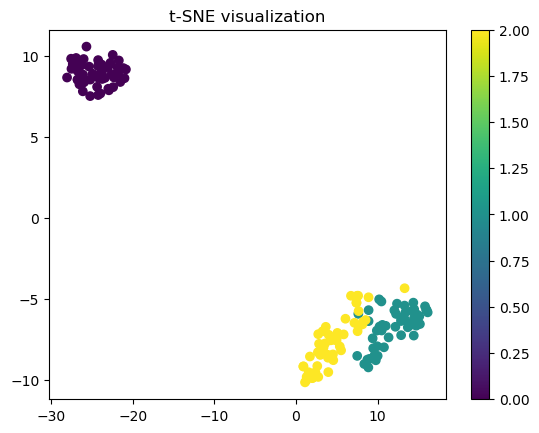

In [7]:
from sklearn.datasets import load_iris
import pandas as pd

X, y = load_iris(return_X_y=True, as_frame=True)
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Initialize t-SNE
tsne = TSNE(n_components=2)

# Fit and transform the dataset
X_tsne = tsne.fit_transform(X)

# Visualize the result
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='viridis')
plt.colorbar()
plt.title("t-SNE visualization")
plt.show()


In [ ]:
#4.
